### Get Data Loader

In [1]:
import os
import torch
import numpy as np
import random
from datetime import datetime
from tqdm import tqdm  

# --- Project-specific imports ---
import config as cfg
import utils.data as data_utils

torch.manual_seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
random.seed(cfg.random_seed)

print("Imports complete. Ready to set up the training run.\n")

train_dataloader, val_dataloader, test_dataloader = data_utils.get_3_dataloaders()
val_ood_dataloader, test_ood_dataloader = data_utils.get_ood_dataloaders()

cfg.apply_matplotlib_styles()

def save_pdf_fig(fig, filename):
    
    if not filename.endswith('.pdf'):
        filename += '.pdf'
    
    save_path = os.path.join(cfg.FIGURE_SAVE_DIR, filename)
    os.makedirs(cfg.FIGURE_SAVE_DIR, exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight')

/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports complete. Ready to set up the training run.

 Total dataset size 	: 230
 Train dataset size 	: 138
 Val dataset size 	: 46
 Test dataset size 	: 46

Found 10 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Potamogeton robbinsii', 'Ranunculus aquatilis']

OOD split complete:
  OOD Validation set size: 16
  OOD Test set size    : 17

Global Matplotlib styles applied.


### Load model file

In [2]:
from utils.model import load_model
MODEL_PATH = cfg.best_model_path
print(f"Loading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)

Loading model from: /home/takayuki/Desktop/summer2025/plants/training/phase7/models/best_ood_acc_model_07-31_04-19--55_ph7_gated_attn_actual_convnextv2_tiny.fcmae_ft_in22k_in1k.pth
Model loaded successfully from /home/takayuki/Desktop/summer2025/plants/training/phase7/models/best_ood_acc_model_07-31_04-19--55_ph7_gated_attn_actual_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Evaluation

In [3]:
from utils.evaluate import EvalClassification

test_eval = EvalClassification(model, test_dataloader)
test_eval.evaluate_accuracy()

  -- Evaluating: 100%|██████████| 46/46 [00:12<00:00,  3.58it/s]

Accuracy: 0.8478


0.8478260869565217

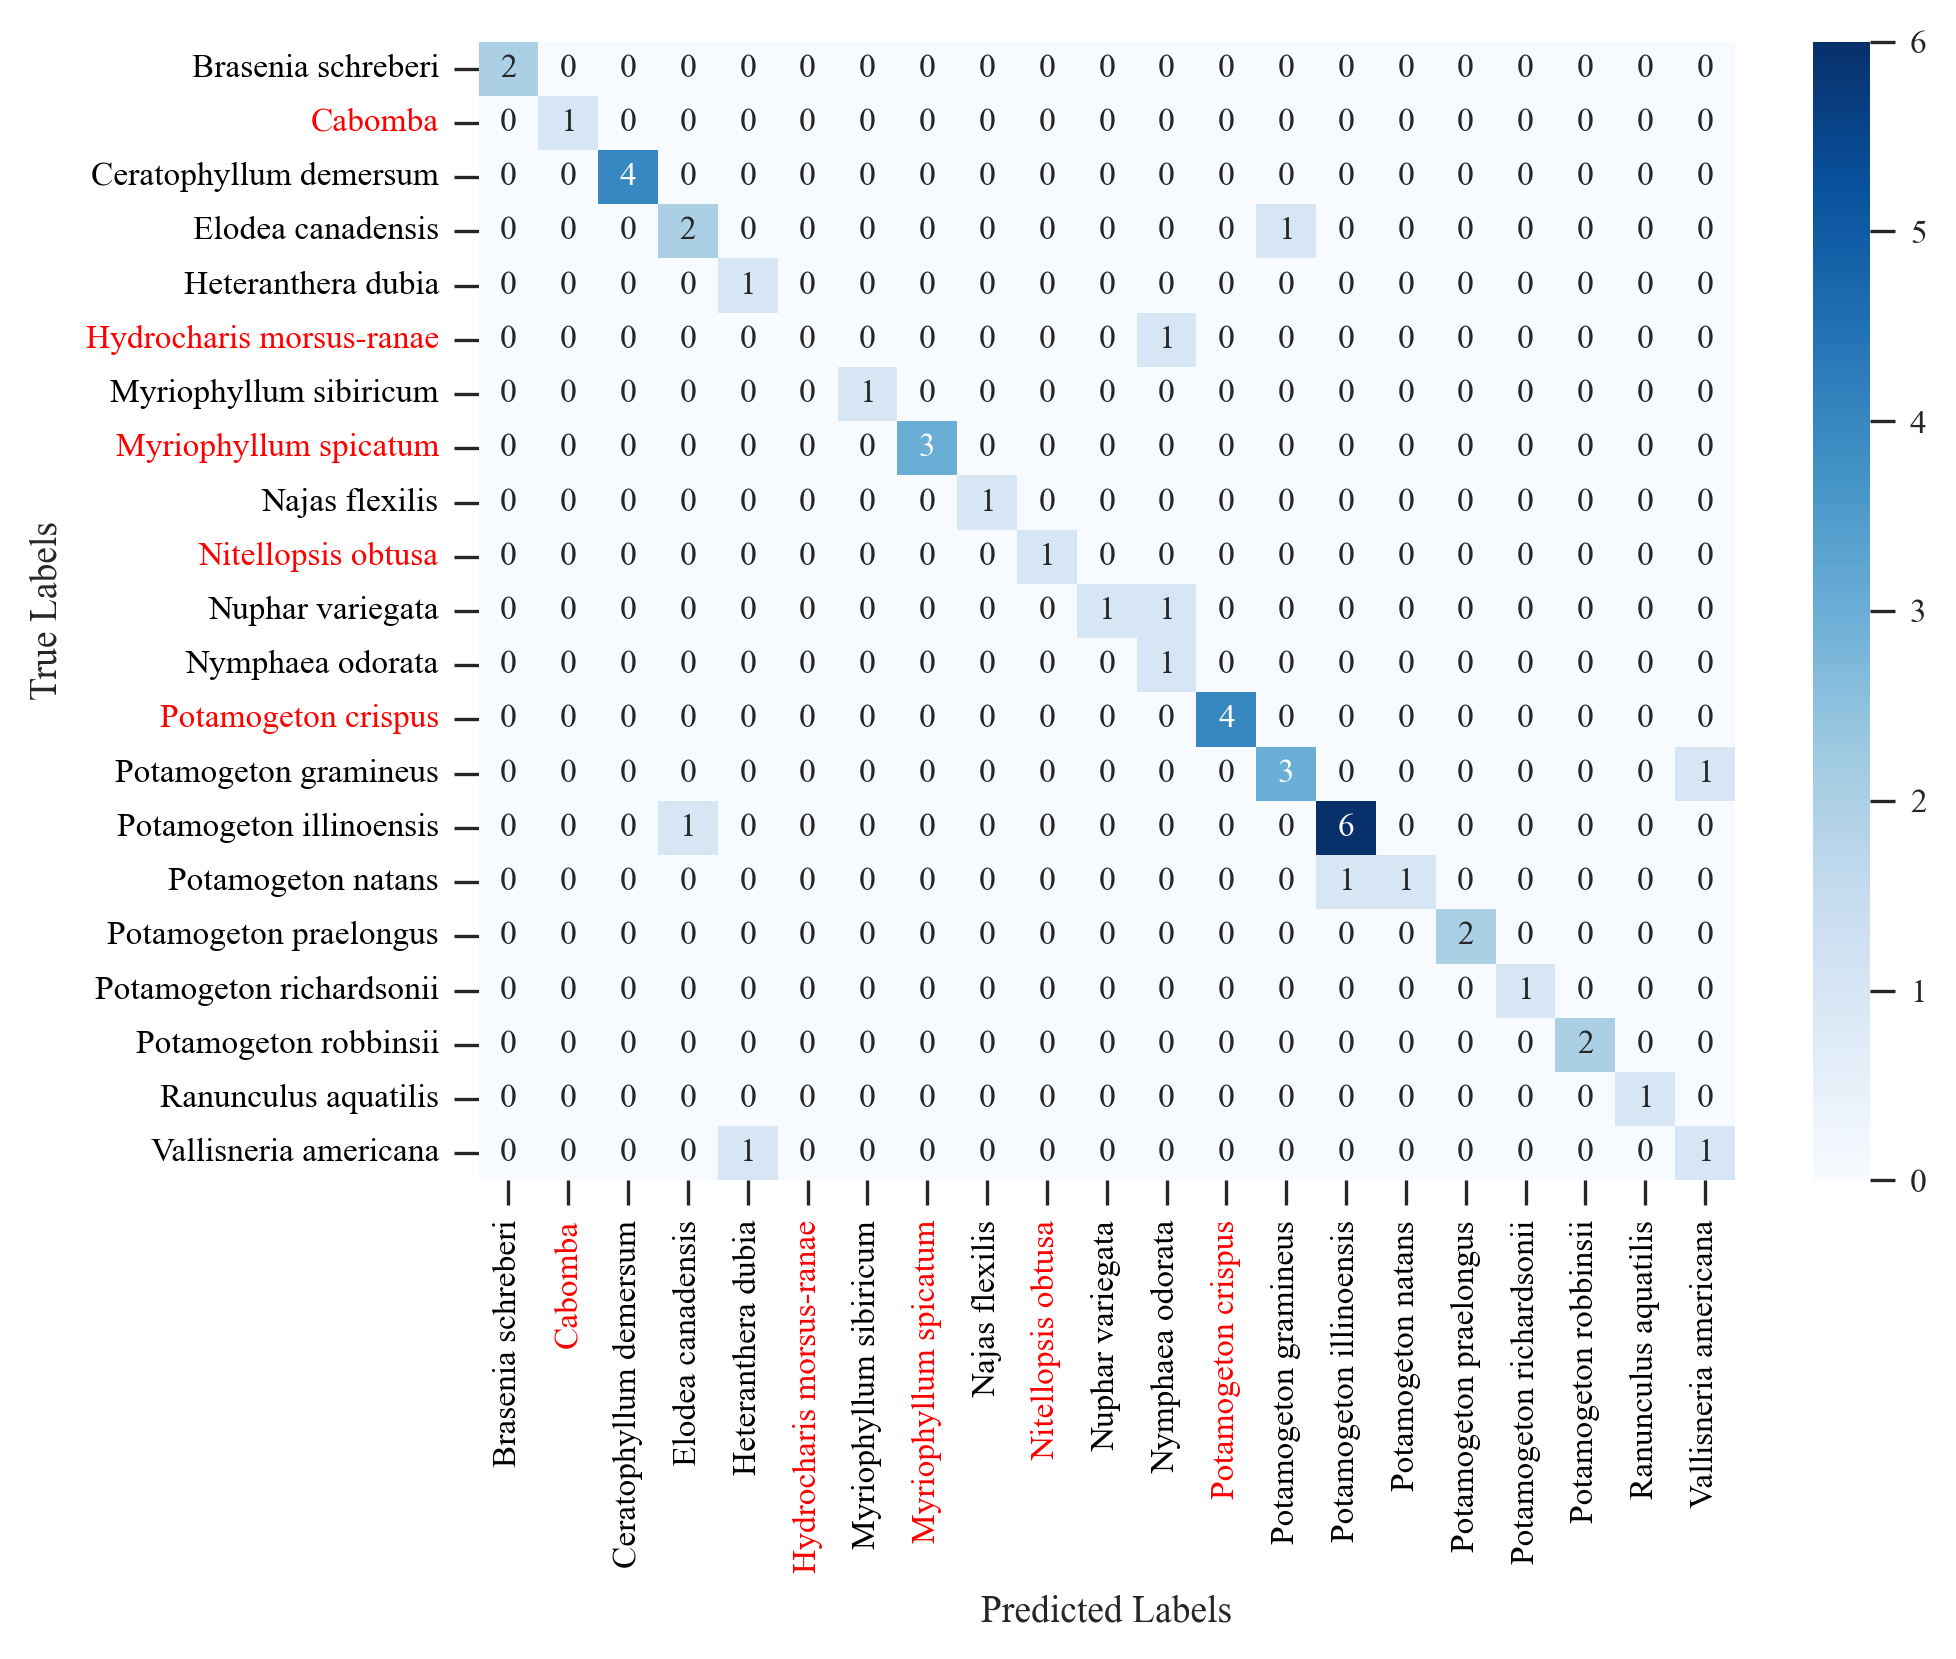


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+----------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |      FNR |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+==========+============+=====================+===========+
| Brasenia schreberi       |         2 |    2 |    0 |    0 |    1        |       1        | 0        |   1        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+----------+------------+---------------------+-----------+
| Cabomba                  |         1 |    1 |    0 |    0 |    1        |       1        | 0        |   1        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------

In [4]:
_, fig = test_eval.get_classwise_confusion_matrix(return_fig=True)
summary_metrics = test_eval.get_classwise_metrics()
# save_pdf_fig(fig, 'test_classwise_cm')

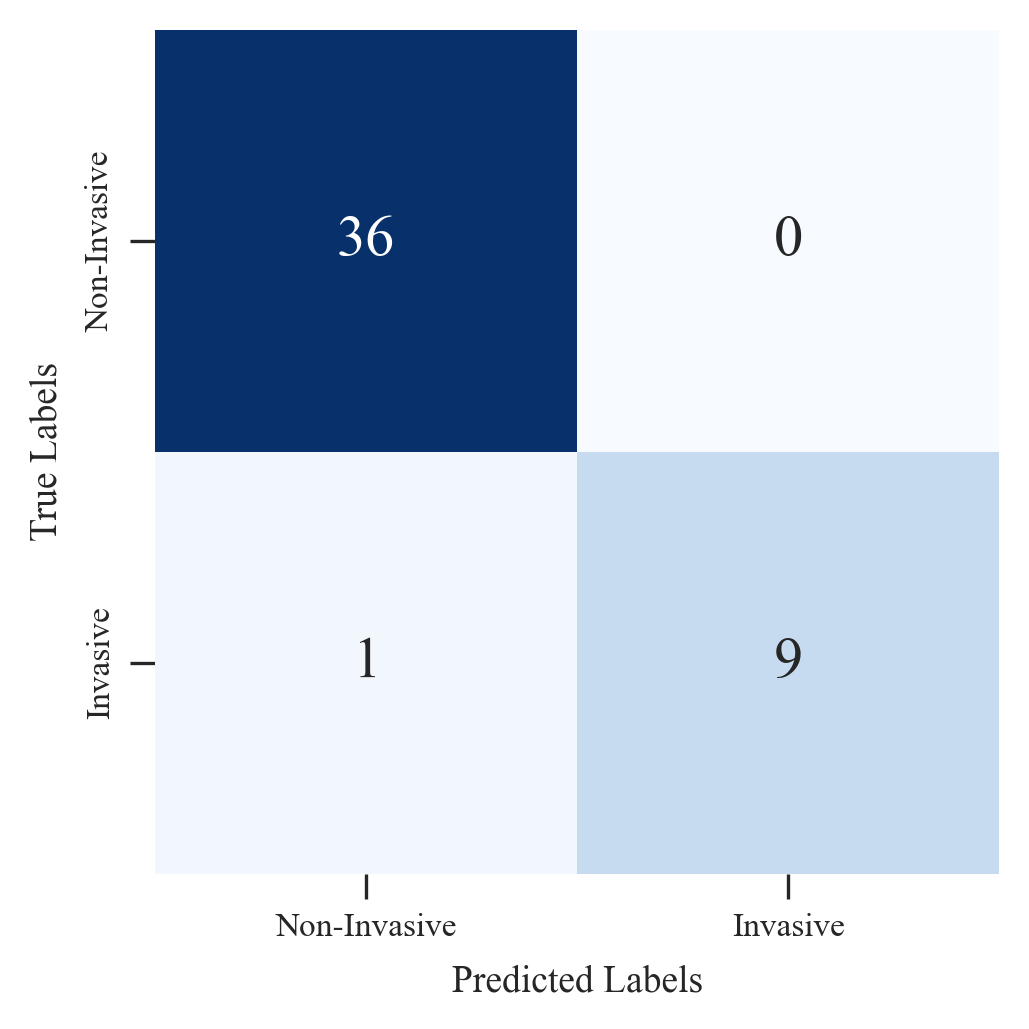


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        9 | False Positive Rate (FPR)      |       0   | Negative Predictive Value (NPV) |    0.973  |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       36 | False Negative Rate (FNR)      |       0.1 | Positive " (PPV or Precision)   |    1      |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        0

In [5]:
_, fig = test_eval.get_binary_confusion_matrix(return_fig=True)
binary_matrics = test_eval.get_binary_metrics()
# save_pdf_fig(fig, 'test_binary_cm')

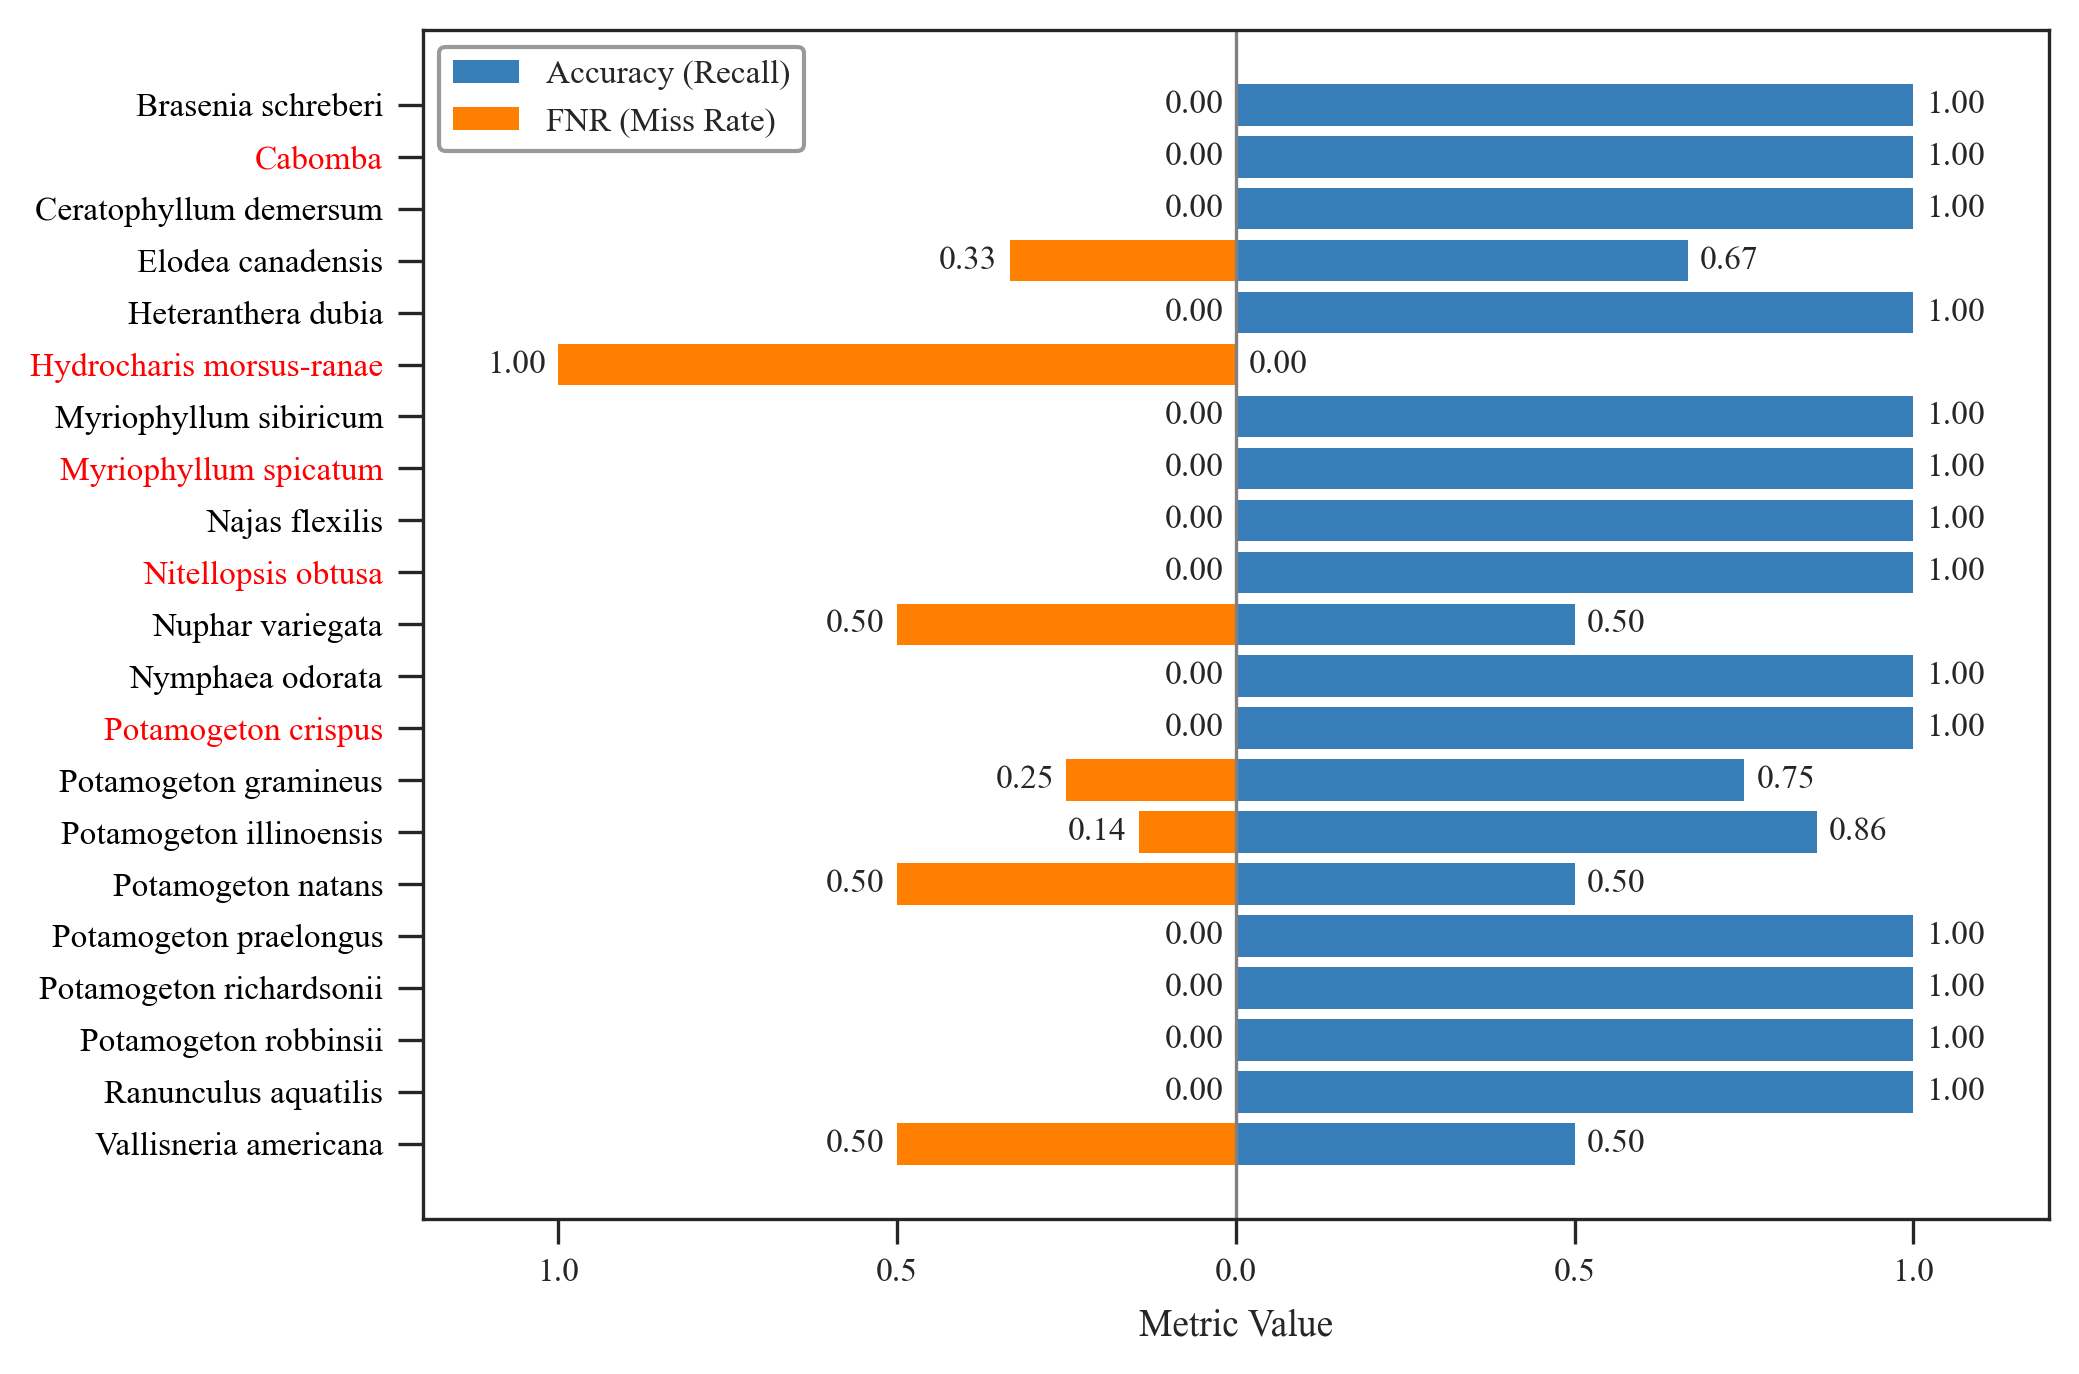

In [6]:
fig = test_eval.visualize_classwise_metrics(return_fig=True)
# save_pdf_fig(fig, 'test_classwise_metrics')

## Hand dataset

In [7]:
hand_eval = EvalClassification(model, val_ood_dataloader)
hand_eval.evaluate_accuracy()

  -- Evaluating: 100%|██████████| 16/16 [00:02<00:00,  7.17it/s]

Accuracy: 0.6250


0.625

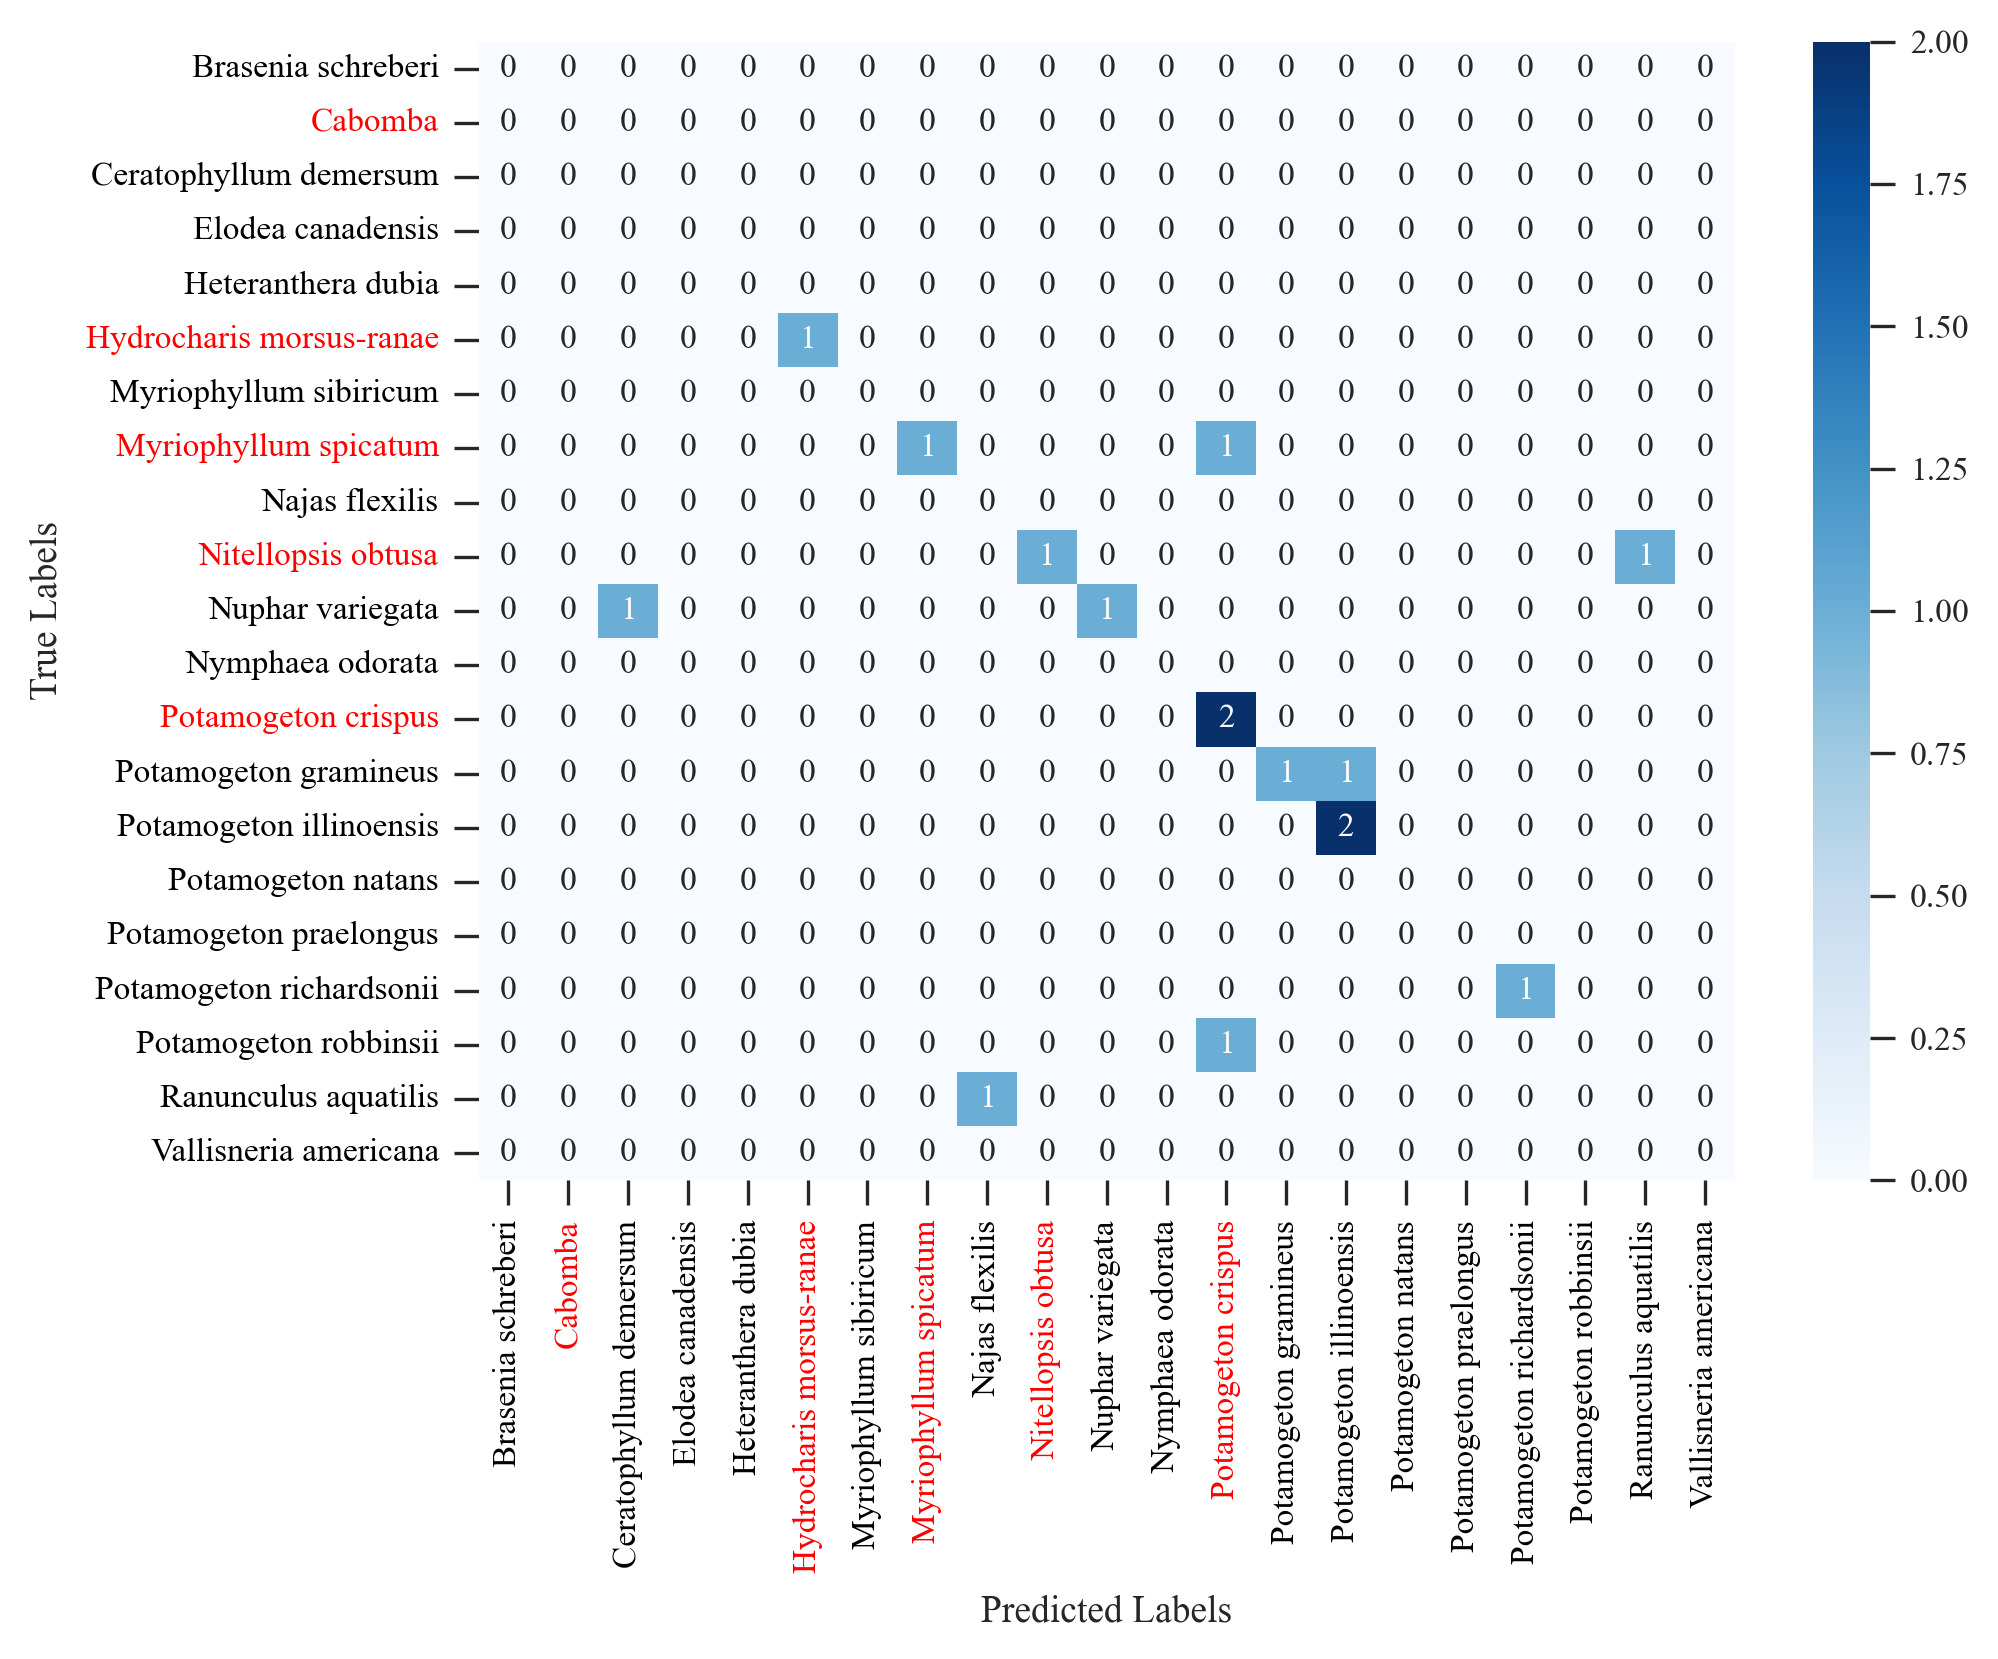

In [8]:
_, fig = hand_eval.get_classwise_confusion_matrix(return_fig=True)
save_pdf_fig(fig, 'ood_classwise_cm')

In [9]:
hand_eval.get_classwise_metrics()


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+-------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   FNR |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+=======+============+=====================+===========+
| Brasenia schreberi       |         0 |    0 |    0 |    0 |    0        |            0   |   0   |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+-------+------------+---------------------+-----------+
| Cabomba                  |         0 |    0 |    0 |    0 |    0        |            0   |   0   |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+

{'classwise_data': [['Brasenia schreberi',
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   0.0,
   0.0,
   0.0,
   0.0,
   np.float64(1.0),
   np.float64(0.0)],
  ['Cabomba',
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   0.0,
   0.0,
   0.0,
   0.0,
   np.float64(1.0),
   np.float64(0.0)],
  ['Ceratophyllum demersum',
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(1),
   np.float64(0.0),
   0.0,
   0.0,
   0.0,
   np.float64(0.9375),
   np.float64(0.0625)],
  ['Elodea canadensis',
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   0.0,
   0.0,
   0.0,
   0.0,
   np.float64(1.0),
   np.float64(0.0)],
  ['Heteranthera dubia',
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   0.0,
   0.0,
   0.0,
   0.0,
   np.float64(1.0),
   np.float64(0.0)],
  ['Hydrocharis morsus-ranae',
   np.int64(1),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.0),
   np.f

In [10]:
hand_eval.print_definitions()


Definitions of Metrics:
TP:  True Positives - Invasive species correctly classified as Invasive
TN:  True Negatives - Non-Invasive species correctly classified as Non-Invasive
FP:  False Positives - Non-Invasive species incorrectly classified as Invasive
FN:  False Negatives - Invasive species incorrectly classified as Non-Invasive
FPR:  False Positive Rate - Proportion of Non-Invasive species incorrectly classified as Invasive
FNR:  False Negative Rate - Proportion of Invasive species incorrectly classified as Non-Invasive {IMPORTANT!}
TNR:  True Negative Rate (Specificity) - Proportion of Non-Invasive species correctly classified
TPR:  True Positive Rate (Recall or Sensitivity) - Proportion of Invasive species correctly classified
PPV:  Positive Predictive Value (Precision) - Proportion of predicted Invasive species that are actually Invasive
NPV:  Negative Predictive Value - Proportion of Non-Invasive predictions that are actually Non-Invasive
F1 Score:  Harmonic mean of Precision 

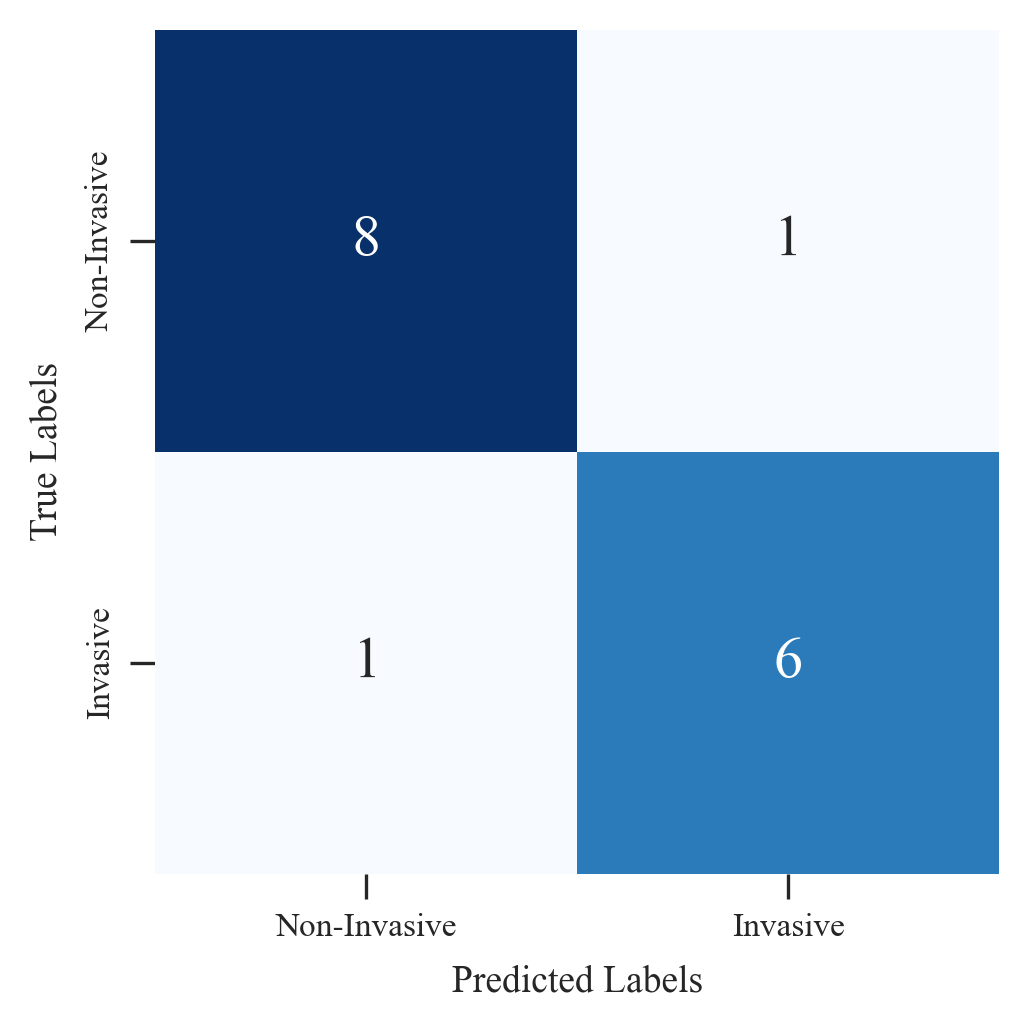

In [11]:
_, fig = hand_eval.get_binary_confusion_matrix(return_fig=True)
save_pdf_fig(fig, 'ood_binary_cm')

In [12]:
bin_metrics = hand_eval.get_binary_metrics()


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        6 | False Positive Rate (FPR)      |    0.1111 | Negative Predictive Value (NPV) |    0.8889 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |        8 | False Negative Rate (FNR)      |    0.1429 | Positive " (PPV or Precision)   |    0.8571 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        1

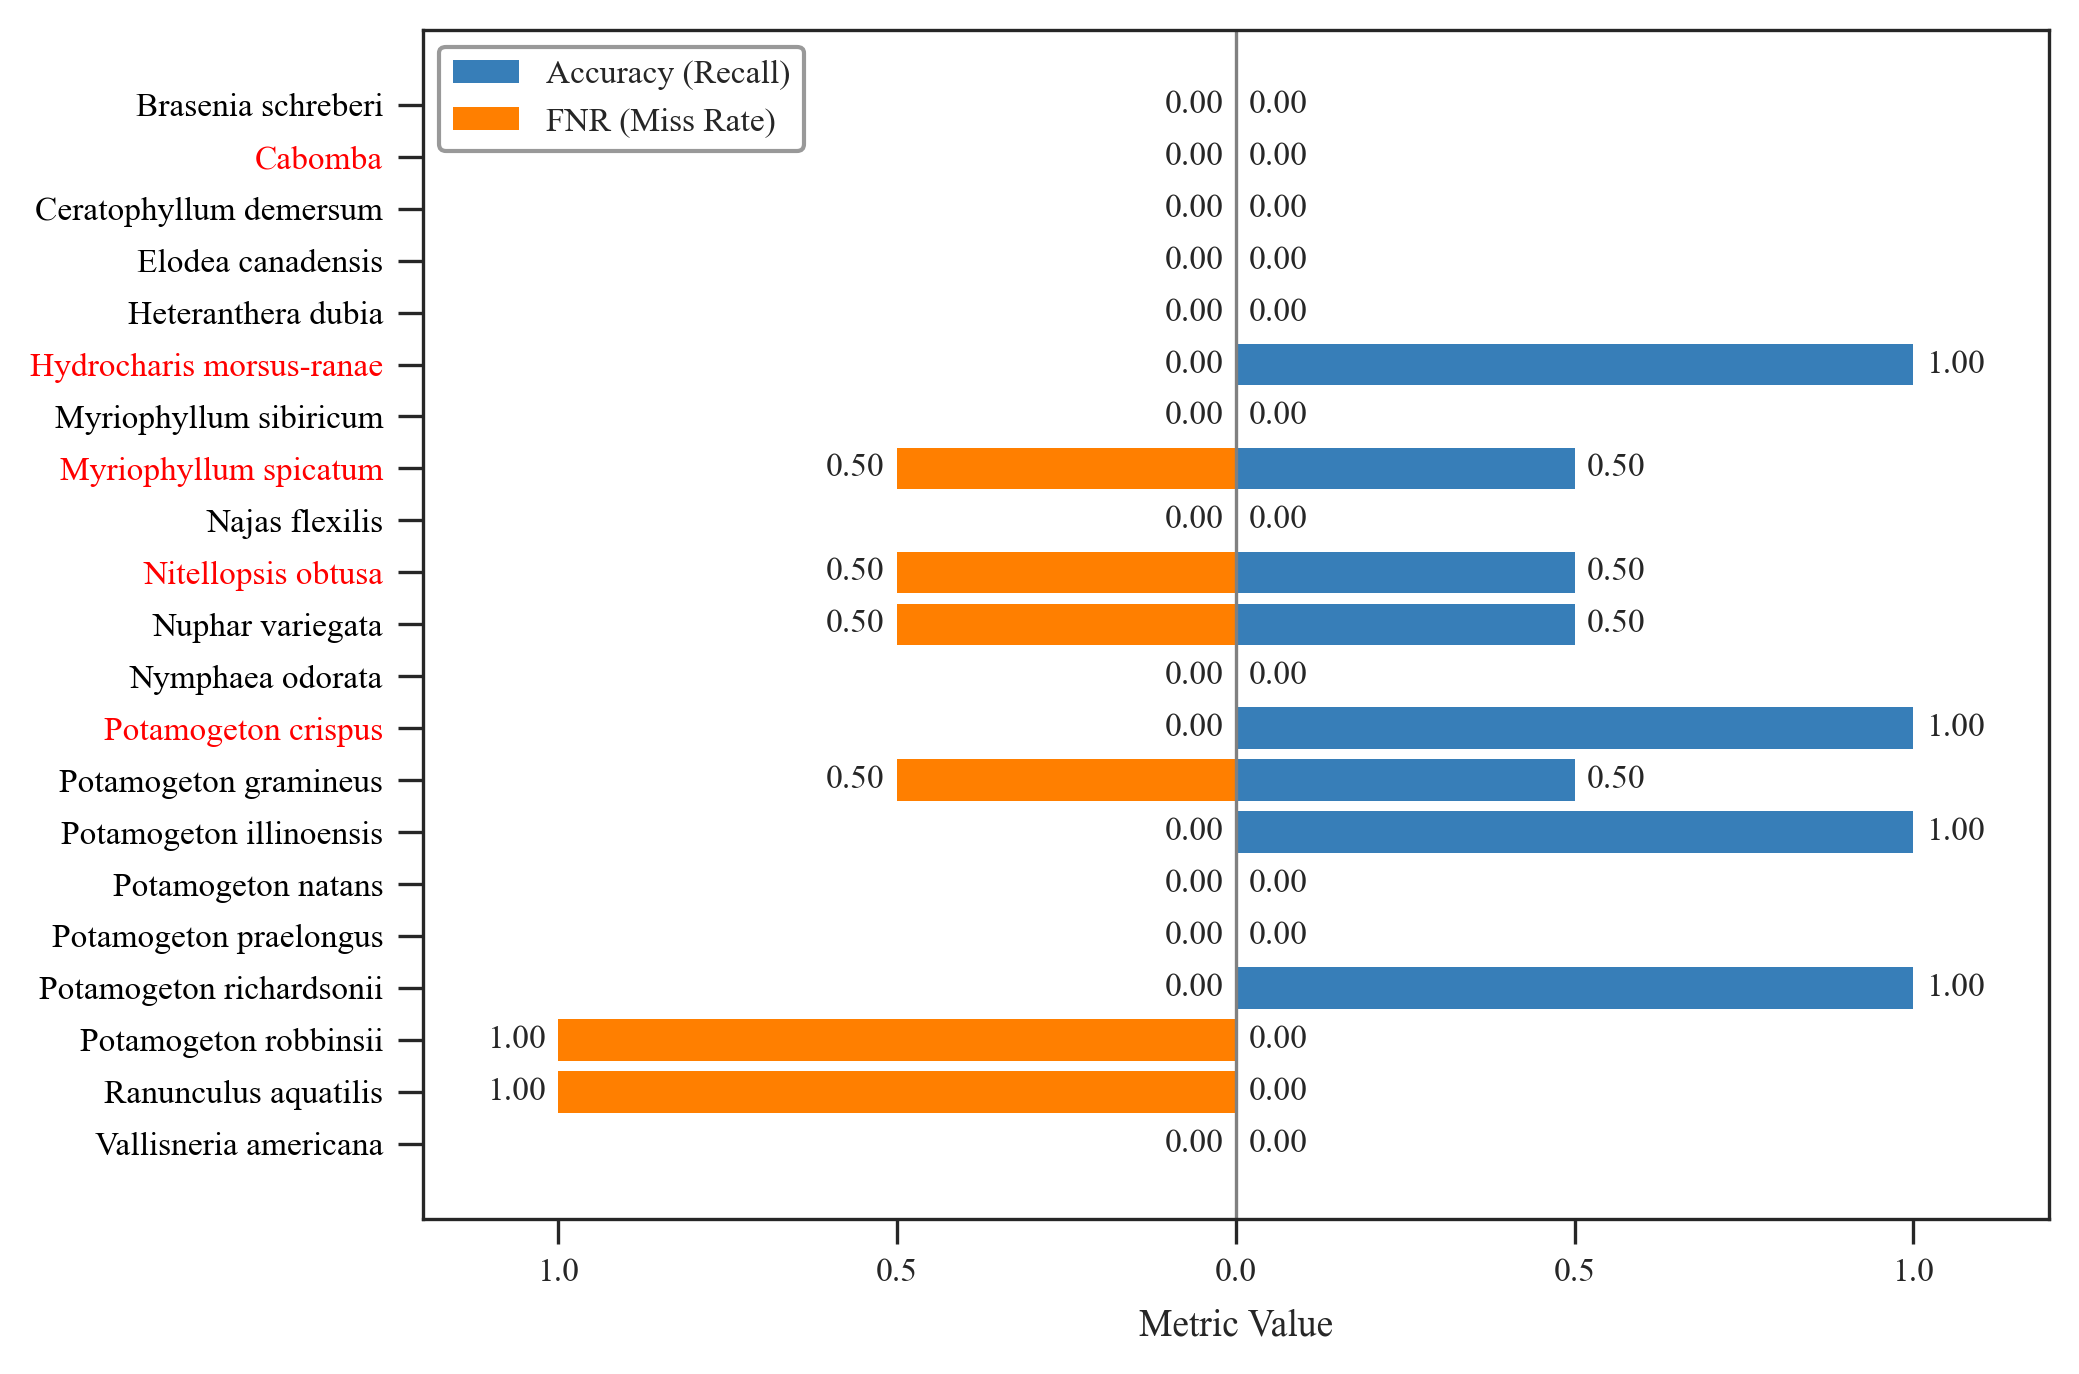

In [13]:
fig = hand_eval.visualize_classwise_metrics(return_fig=True)

  -- Evaluating: 100%|██████████| 138/138 [00:31<00:00,  4.40it/s]


Accuracy: 0.9275


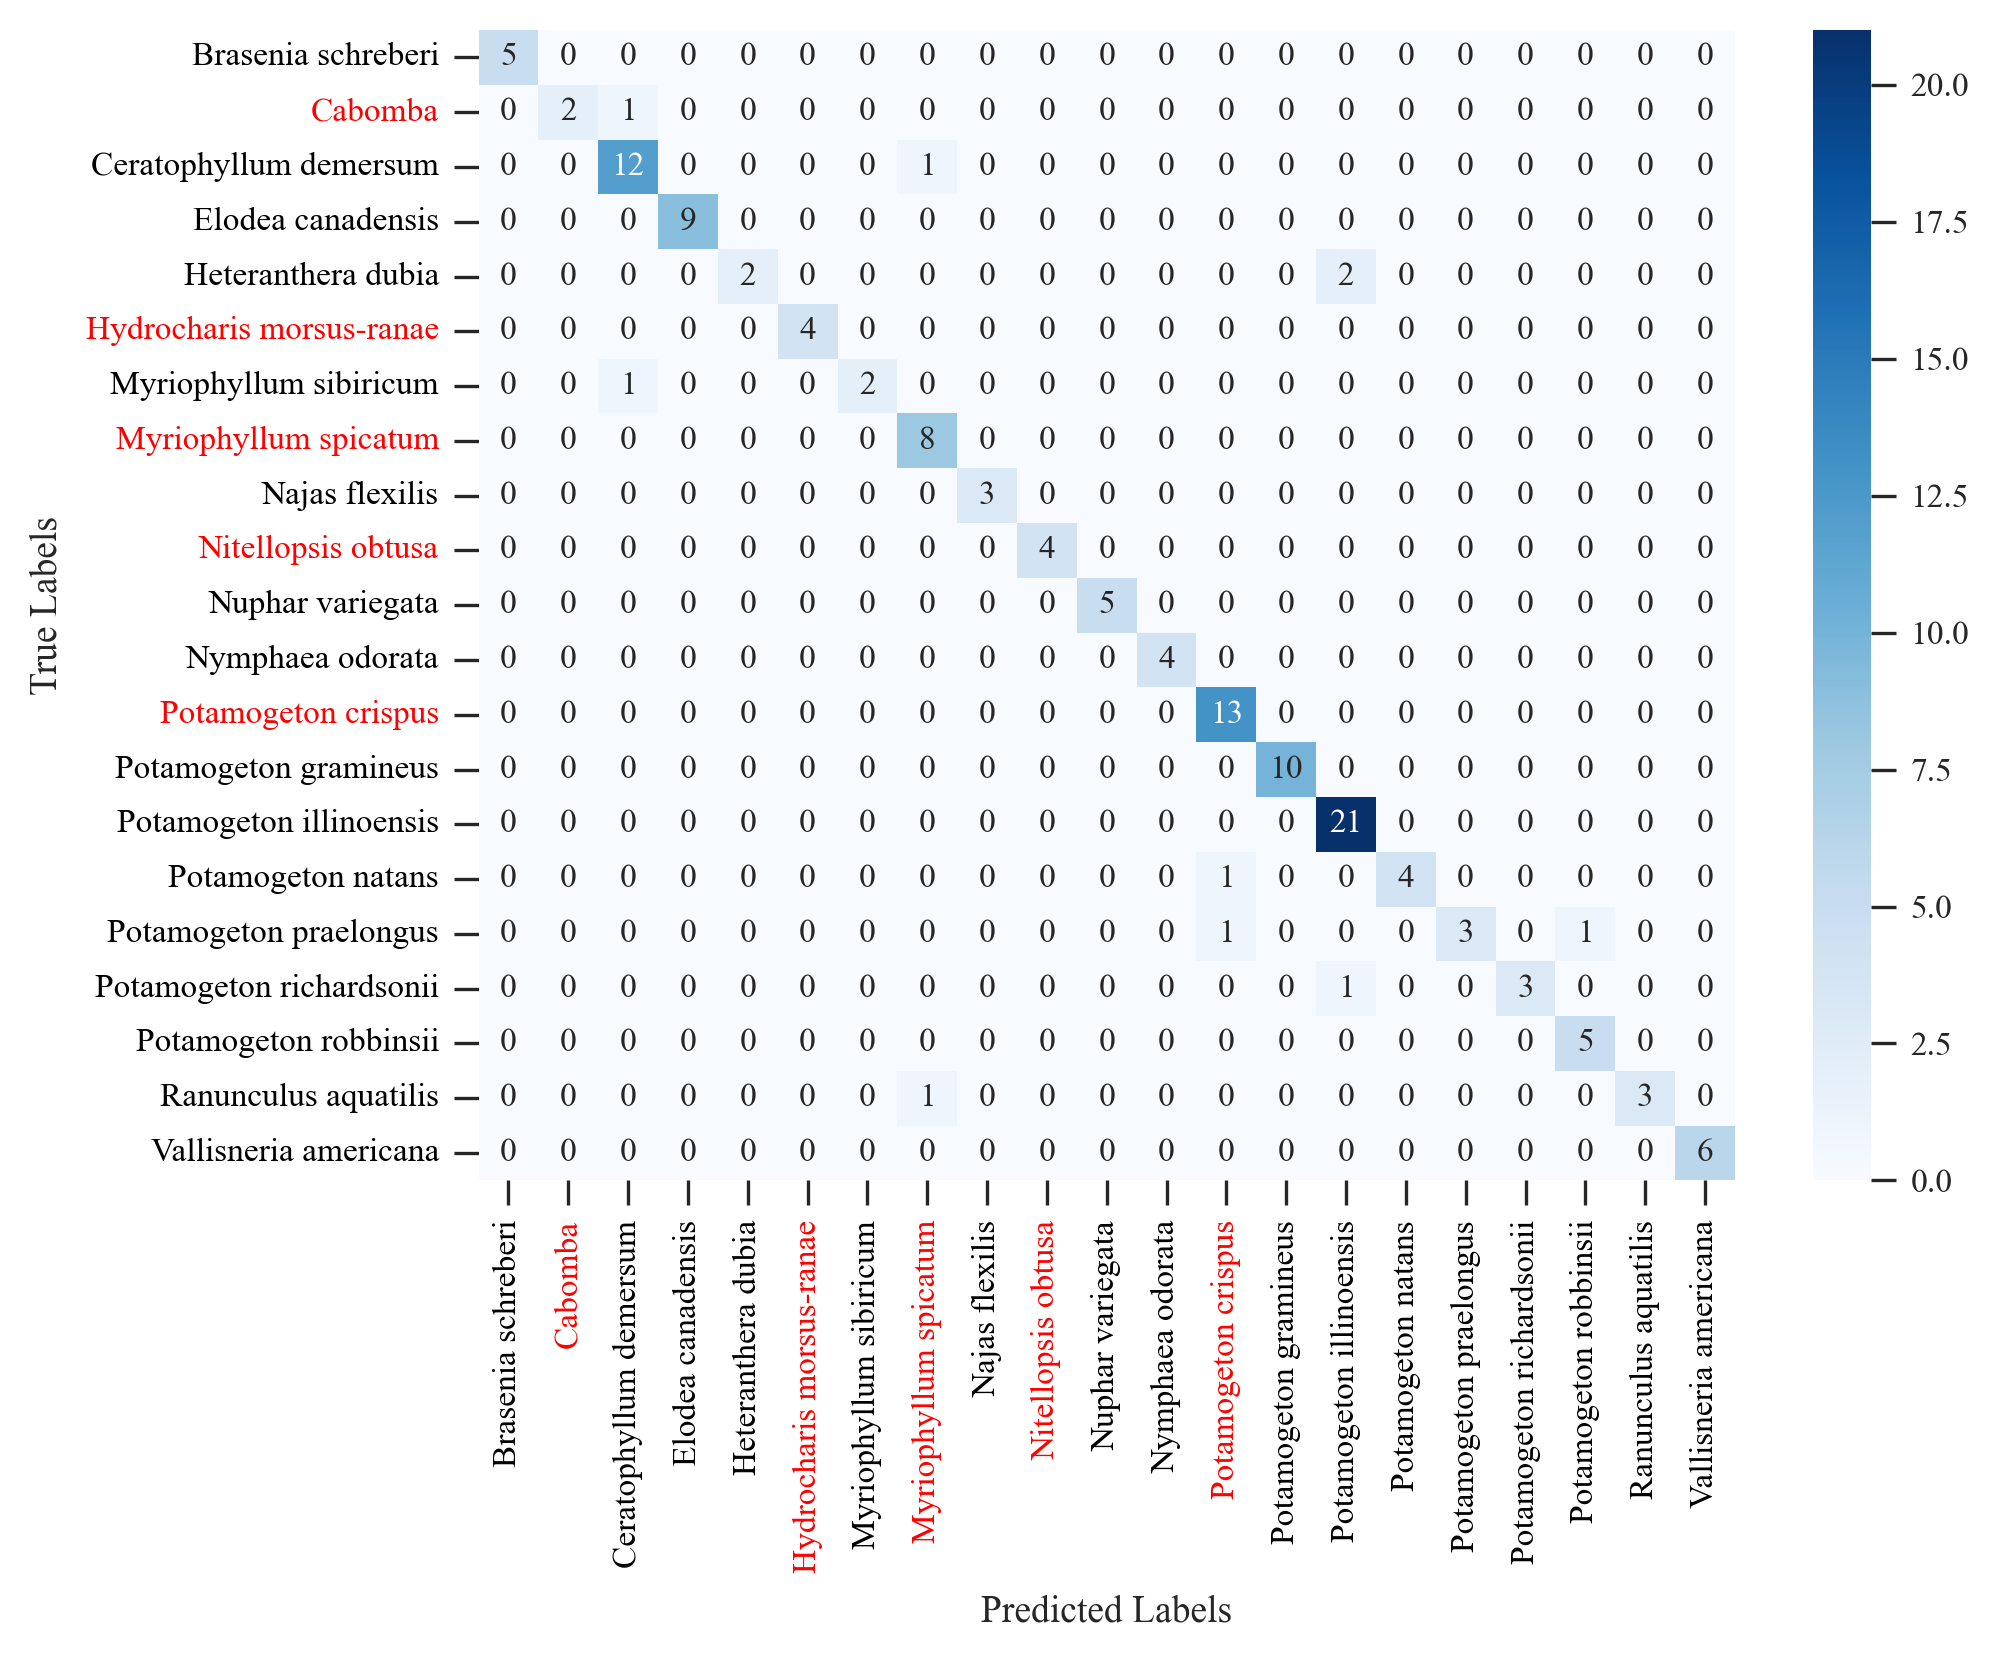

In [14]:
train_eval = EvalClassification(model, train_dataloader)
train_eval.evaluate_accuracy()
_, fig = train_eval.get_classwise_confusion_matrix(return_fig=True)
save_pdf_fig(fig, 'train_classwise_cm')

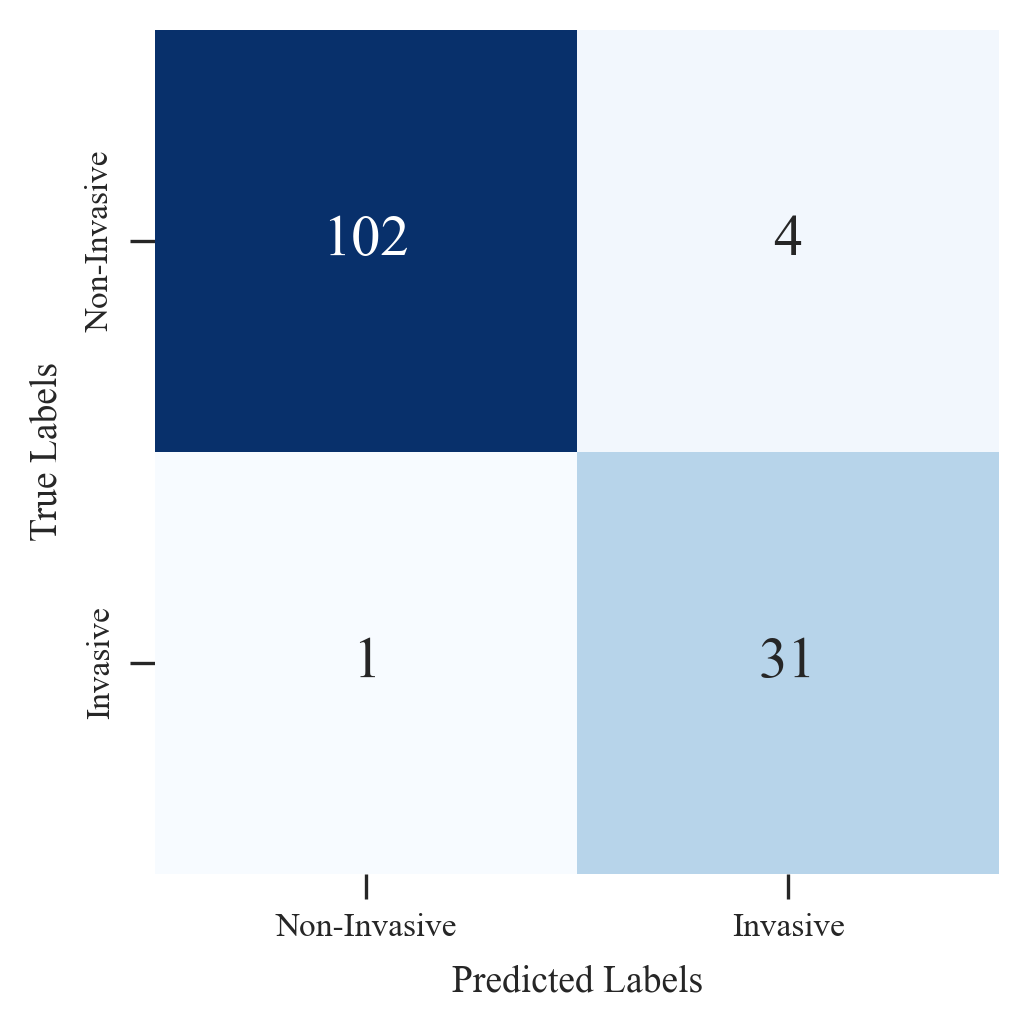

array([[102,   4],
       [  1,  31]])

In [15]:
train_eval.get_binary_confusion_matrix()

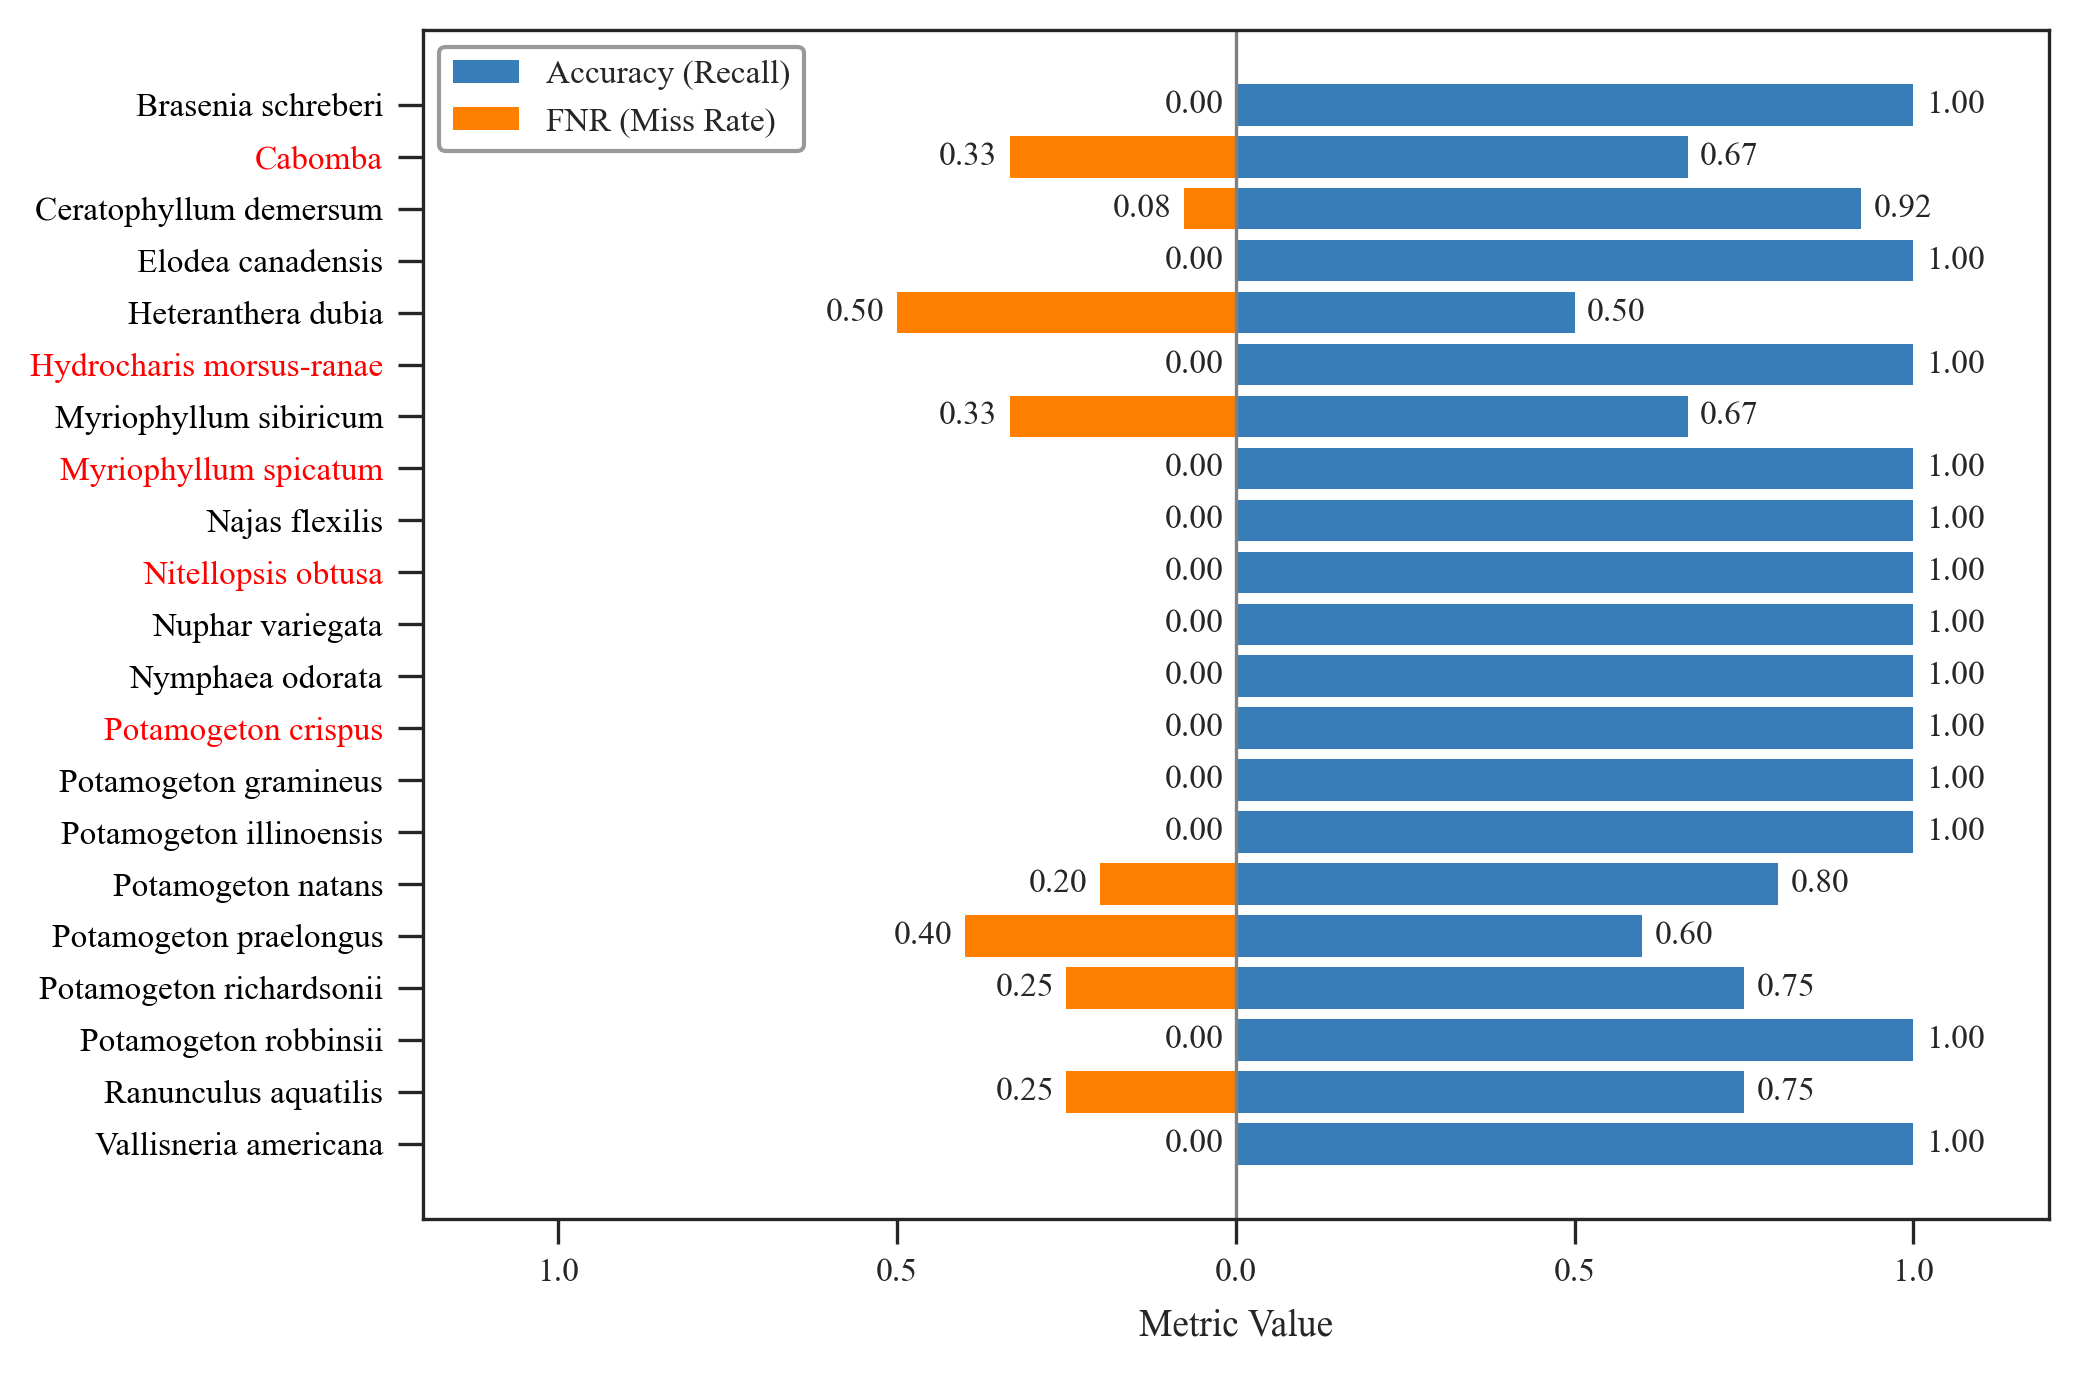

In [16]:
train_eval.visualize_classwise_metrics()

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/squared_reflected
Found 21 classes locally: ['Brasenia schreberi', 'Cabomba', 'Ceratophyllum demersum', 'Elodea canadensis', 'Heteranthera dubia', 'Hydrocharis morsus-ranae', 'Myriophyllum sibiricum', 'Myriophyllum spicatum', 'Najas flexilis', 'Nitellopsis obtusa', 'Nuphar variegata', 'Nymphaea odorata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton natans', 'Potamogeton praelongus', 'Potamogeton richardsonii', 'Potamogeton robbinsii', 'Ranunculus aquatilis', 'Vallisneria americana']
Remapped 230 images to use canonical indices.
Total dataset size 	: 230
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 230

Test DataLoader created with 230 images from /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/squared

  -- Evaluating:   0%|          | 0/230 [00:00<?, ?it/s]

  -- Evaluating: 100%|██████████| 230/230 [00:42<00:00,  5.35it/s]


Accuracy: 0.9391


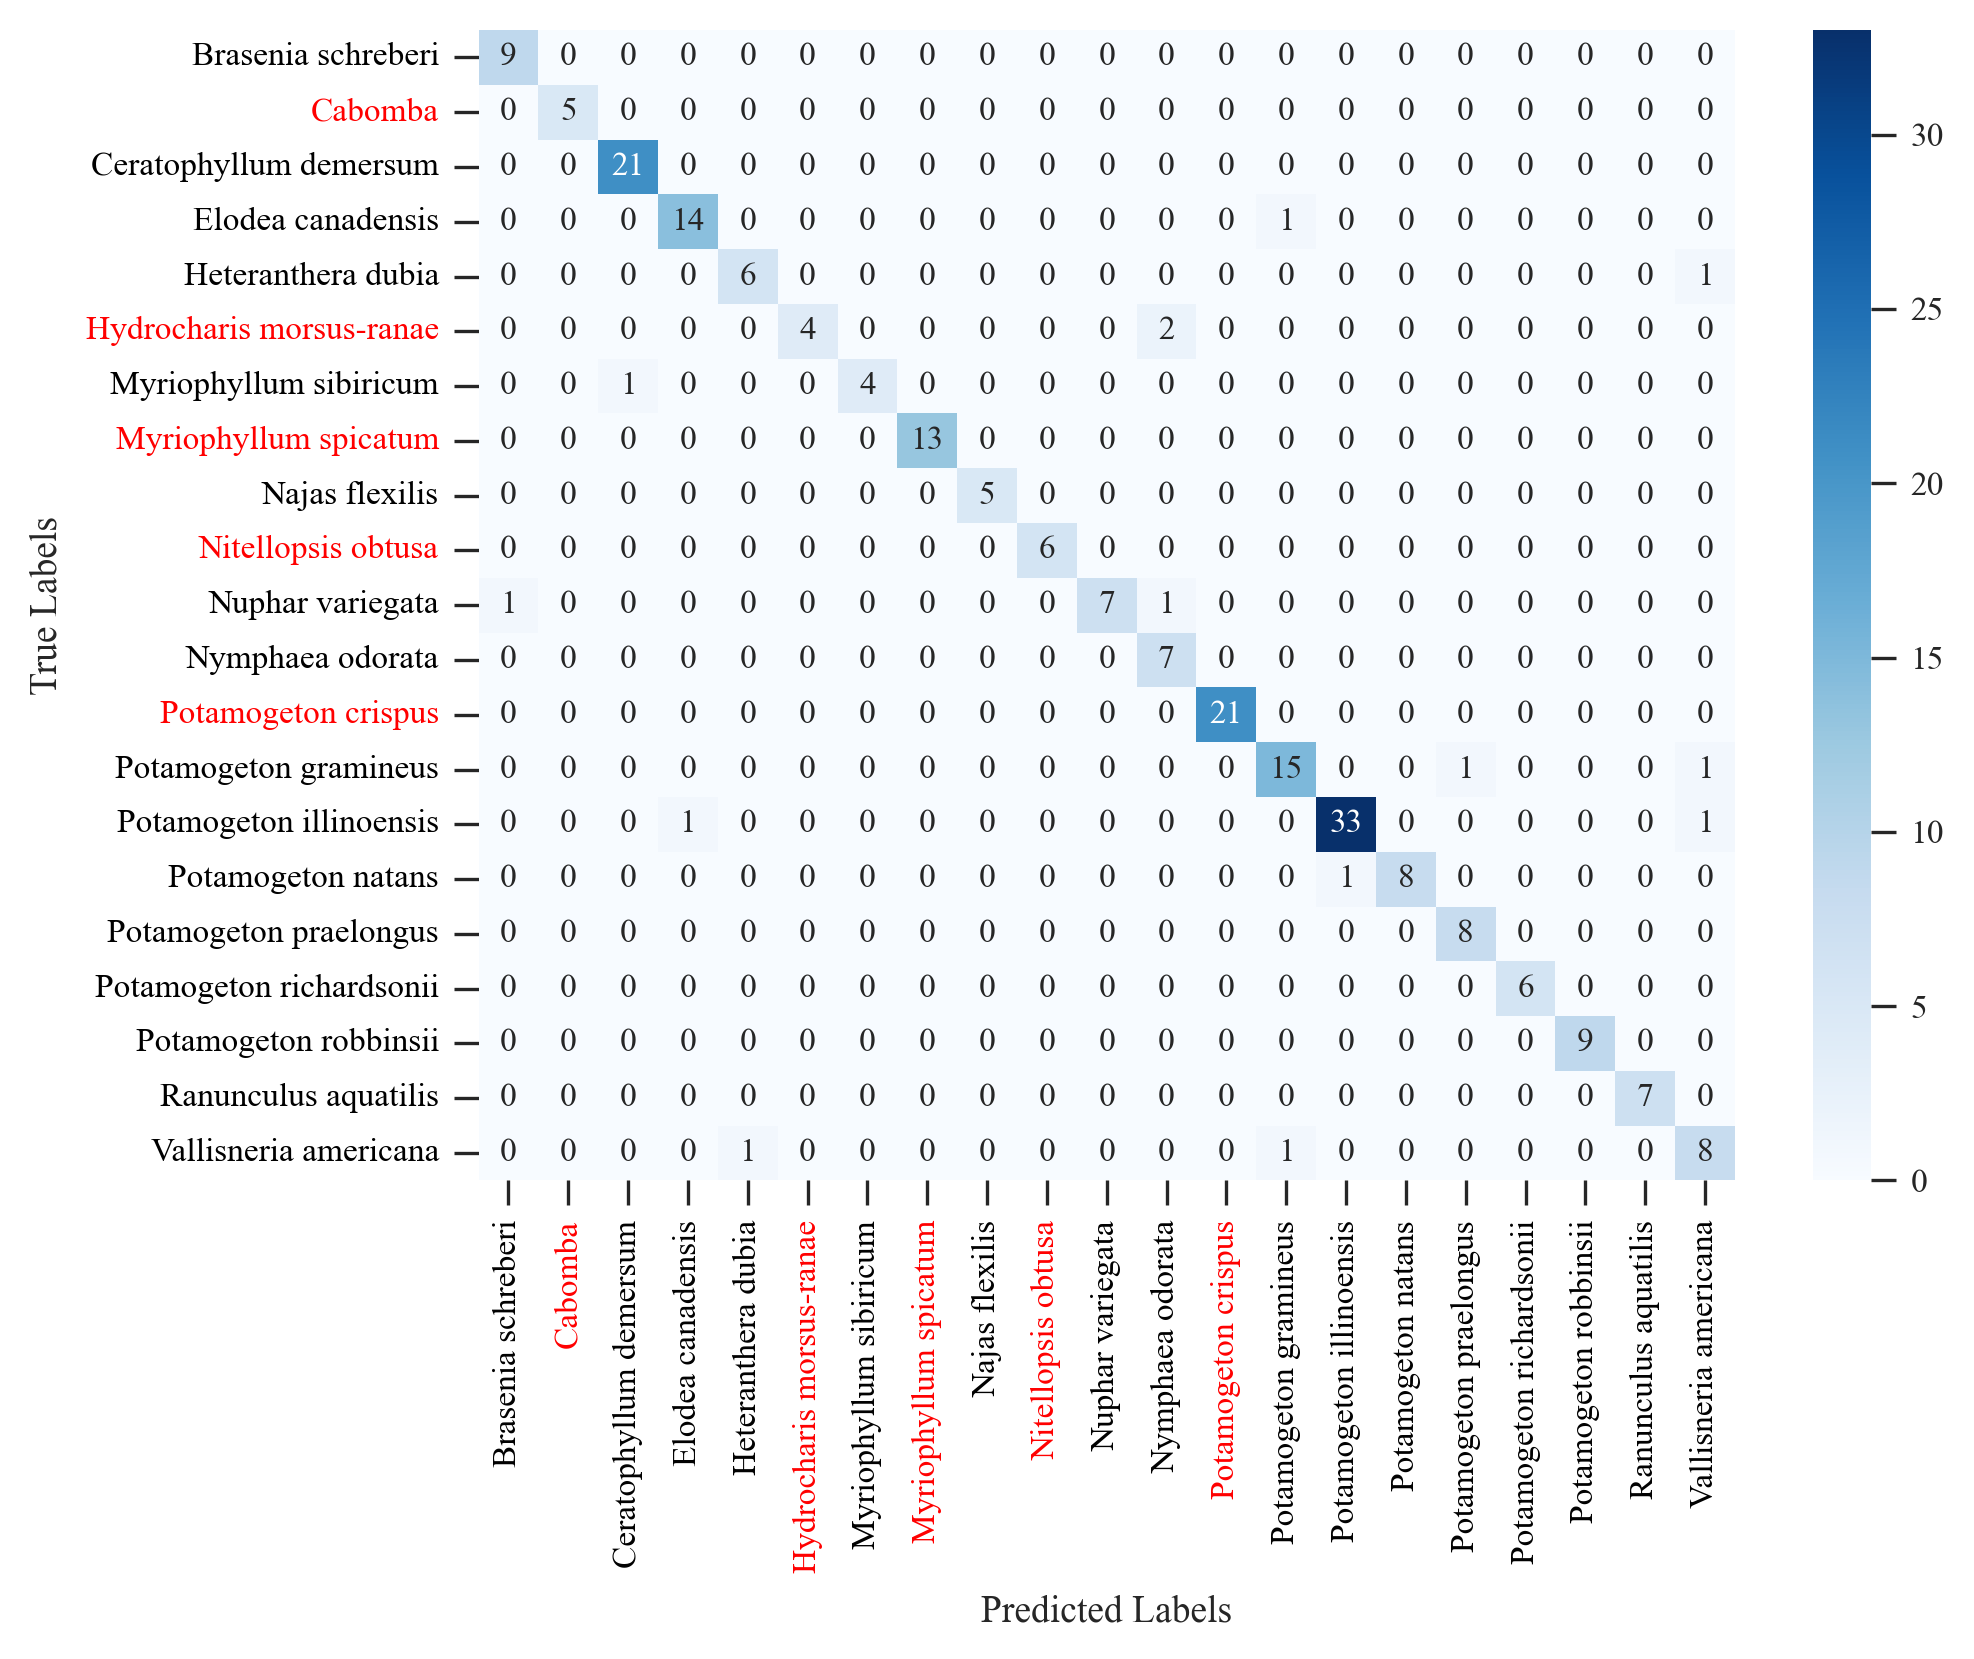

In [17]:
full_dataloader = data_utils.get_test_dataloader(test_data_dir=cfg.SQUARED_RELECTED_DIR)
full_eval = EvalClassification(model, full_dataloader)
full_eval.evaluate_accuracy()
_, fig = full_eval.get_classwise_confusion_matrix(return_fig=True)
# save_pdf_fig(fig, 'full_classwise_cm')

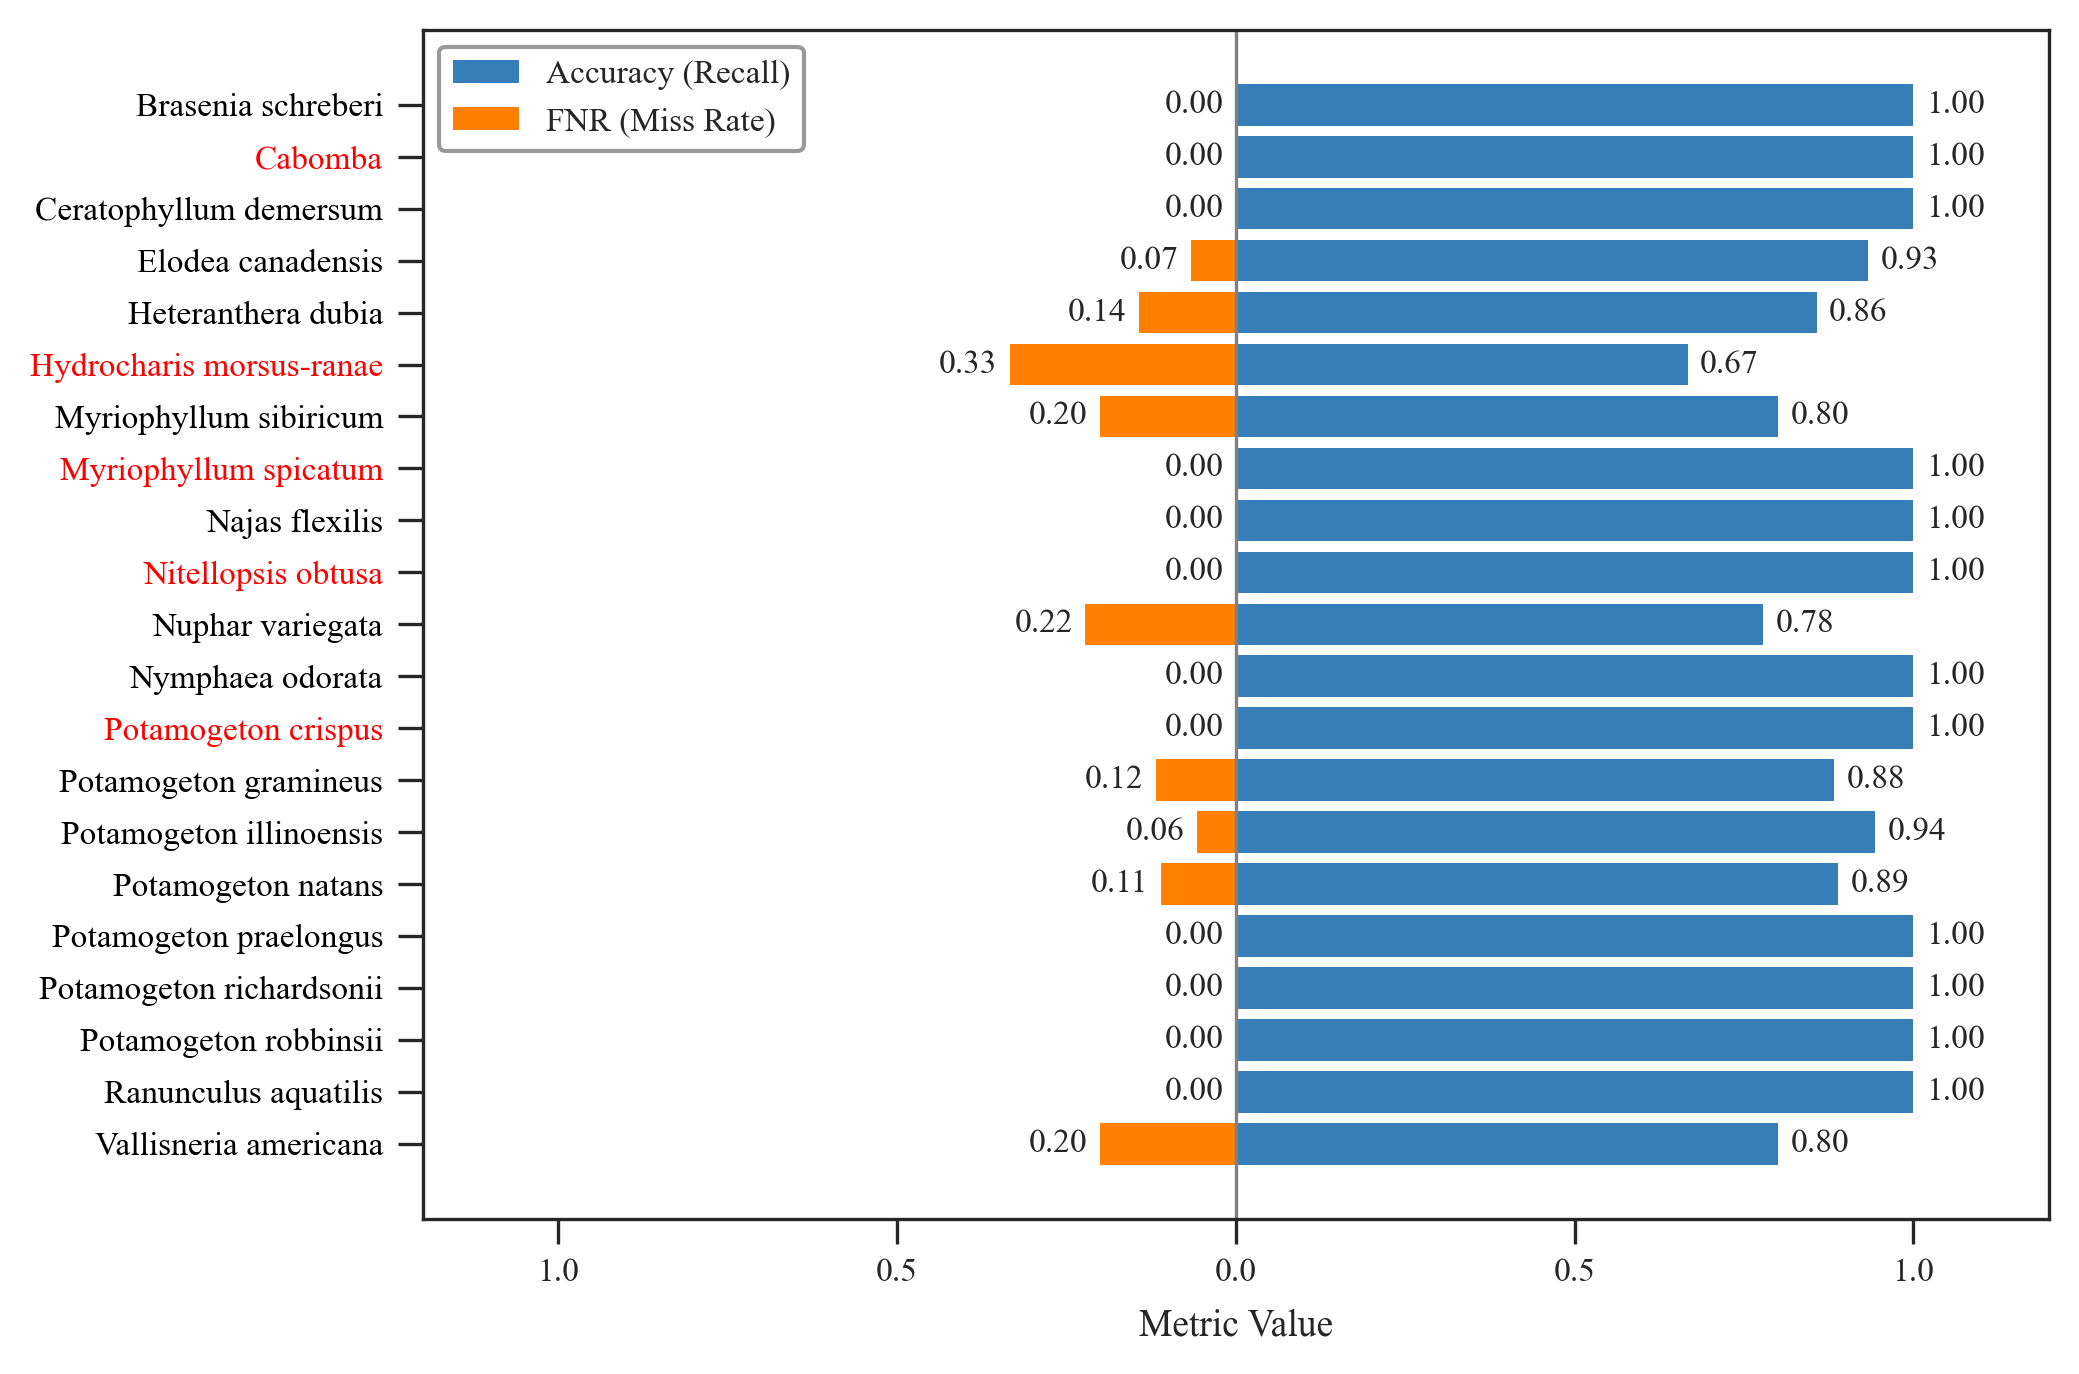

In [18]:
full_eval.visualize_classwise_metrics()